<a href="https://colab.research.google.com/github/seanwu-bit/Automated-Regional-Impact-Auditor-ARIA-/blob/aria_9.5/Aria_v9_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 14 Homework: ARIA v9.5 — The Resilience Monitor

**Course:** NTU Remote Sensing & Spatial Information Analysis (遙測與空間資訊之分析與應用)  
**Instructor:** Prof. Su Wen-Ray  
**Assignment:** Week 14 Homework  
**Due Date:** See NTUCool (typically 1 week after class)  
**Case Study:** Landsat Multi-Decadal Trend Analysis & Resilience — Xiulin / Taroko Study Area（秀林 / 太魯閣研究區）

---

## Overview

本週你要將 ARIA 系統從 v9.0 升級到 **v9.5 — The Resilience Monitor**。v9.0 使用 Sentinel-2（6 年、數百張影像）進行時序趨勢分析；v9.5 引入 **Landsat 全系列（L5/L7/L8/L9）的波段調和（band harmonization）**，將分析時間軸從 6 年拉長到 **26 年（2000–2026）**，並加入**桃園埤塘消失分析**和**植被韌性指標**，回答指揮官最關鍵的問題：這片土地的長期趨勢是什麼？它有沒有從災害中恢復的能力？

**升級邏輯：**
```
v5.0 (W8)  → 光譜分析引擎：一張影像、一個指標（NDVI）
v6.0 (W9)  → 變遷偵測引擎：兩張影像、一個差值（ΔNDVI）
v7.0 (W10) → SAR 穿雲引擎：一張光學 + 一張 SAR
v8.0 (W12) → 分類引擎：一張影像 → 土地覆蓋圖
v9.0 (W13) → 雲端引擎：數百張影像 → 6 年時序趨勢分析
v9.5 (W14) → 韌性監測引擎：數千張影像 → 26 年長期趨勢 + 韌性分析 ⬆
```

**Key Deliverable:** A Colab/Jupyter notebook (.ipynb) that demonstrates:
- Landsat 多衛星波段調和（L5/L7 → L8/L9 band mapping）
- Collection 2 Level 2 scale factor 校正 + QA_PIXEL 雲遮罩
- 26 年 NDVI / MNDWI / NBR 年均時序分析
- 像素級線性趨勢分析（greening vs. browning）
- 桃園埤塘消失偵測（MNDWI 水頻率圖）
- 植被韌性指標計算（recovery ratio）
- GeoTIFF 匯出（EPSG:32651）

指揮官現在需要的是**長期脈絡（long-term context）**。W13 的 6 年 Sentinel-2 時序已經證明了時序分析的威力，但 6 年太短了——指揮官的問題是跨越世代的：

- 「2024 年地震造成的植被損失是前所未有的，還是這個地區過去也經歷過類似規模的擾動？」
- 「桃園台地的埤塘在過去 26 年消失了多少？對都市防洪有什麼影響？」
- 「地震後植被有恢復的跡象嗎？這片土地的韌性（resilience）夠不夠？」

這些問題需要**數十年的觀測記錄**。Sentinel-2 從 2017 年才開始有 L2A 資料，時間不夠長。但 **Landsat 系列**從 1984 年就開始連續觀測——L5（1984–2012）、L7（1999–至今）、L8（2013–至今）、L9（2021–至今）。挑戰在於：不同世代的 Landsat 衛星波段編號不同，必須先做**波段調和（band harmonization）**才能建立一致的長期時序。

> **Important:** The homework study area remains **Xiulin / Taroko**（秀林 / 太魯閣山區）, same as W13. But the temporal depth is vastly different: W13 covered 6 years (2020–2026) with Sentinel-2 at 10m resolution; W14 covers 26 years (2000–2026) with Landsat at 30m resolution. You will discover patterns invisible in a 6-year window — long-term greening/browning trends, pond disappearance in Taoyuan, and the true resilience of ecosystems.

In [ ]:
# ============================================================
# Step: 0 — Environment Setup
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import ee, geemap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import pandas as pd
from datetime import datetime, timedelta
import os, platform

ee.Authenticate()  # Uncomment on first run
ee.Initialize(project='geocode-project-63904')

# --- 中文字型設定（跨平台：Colab / Windows / macOS 皆適用）---
# ──下載並強制掛載中文字型 (最穩定解法) ──
import urllib.request
import matplotlib.font_manager as fm
import seaborn as sns
font_path = "NotoSansTC.otf"
font_url = "https://raw.githubusercontent.com/googlefonts/noto-cjk/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf"
if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)

fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
plt.rc('font', family=prop.get_name())
plt.rcParams['axes.unicode_minus'] = False # 正常顯示負號
sns.set_palette("husl")

plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'PingFang TC', 'Heiti TC', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
try:
    import subprocess
    subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-noto-cjk"],
                   capture_output=True)
    fm._load_fontmanager(try_read_cache=False)
except FileNotFoundError:
    pass  # 非 Linux（Windows / macOS），跳過 apt-get
_cjk_candidates = [
    "Microsoft JhengHei",      # Windows 正黑體
    "PingFang TC",             # macOS 蘋方
    "Noto Sans CJK TC",       # Colab / Linux
    "Heiti TC",                # macOS 黑體
    "WenQuanYi Micro Hei",    # Linux
    "Droid Sans Fallback",    # Android / 舊 Linux
]
_available = {f.name for f in fm.fontManager.ttflist}
_cjk_found = [f for f in _cjk_candidates if f in _available]
if _cjk_found:
    plt.rcParams["font.sans-serif"] = _cjk_found + ["DejaVu Sans"]
    print(f"中文字型: {_cjk_found[0]}")
else:
    print("⚠️ 未找到中文字型，中文標題可能顯示為方框")
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

# --- Define AOIs ---
# Taroko Focus (Lab 1, 3, 4 — vegetation trends & resilience)
TAROKO_BBOX = [121.34526379253053, 24.046021742135874,
               121.85149217685861, 24.35767637905926]
aoi = ee.Geometry.Rectangle(TAROKO_BBOX)

# Taoyuan Plateau — FULL RANGE (D6 水頻率圖)
# 桃園台地完整範圍：西至新豐/湖口海岸，東至龍潭丘陵
TAOYUAN_BBOX = [120.94, 24.83, 121.35, 25.08]
aoi_taoyuan = ee.Geometry.Rectangle(TAOYUAN_BBOX)

# Taoyuan URBANIZATION CORRIDOR (D7 消失偵測聚焦區)
# 中壢、新屋、高鐵桃園站沿線
TAOYUAN_URBAN_BBOX = [121.00, 24.88, 121.28, 25.05]
aoi_taoyuan_urban = ee.Geometry.Rectangle(TAOYUAN_URBAN_BBOX)

point = ee.Geometry.Point([121.5, 24.2])
elev = ee.Image('USGS/SRTMGL1_003').sample(point, 30).first().get('elevation').getInfo()
print(f"  Connectivity OK — Elevation: {elev} m")
print(f"  AOI 1 (Lab 1/3/4): Taroko Focus — {TAROKO_BBOX}")
print(f"  AOI 2 (Lab 2, D6): Taoyuan Full  — {TAOYUAN_BBOX}")
print(f"  AOI 3 (Lab 2, D7): Taoyuan Urban — {TAOYUAN_URBAN_BBOX}")

中文字型: Noto Sans CJK TC
  Connectivity OK — Elevation: 1031 m
  AOI 1 (Lab 1/3/4): Taroko Focus — [121.34526379253053, 24.046021742135874, 121.85149217685861, 24.35767637905926]
  AOI 2 (Lab 2, D6): Taoyuan Full  — [120.94, 24.83, 121.35, 25.08]
  AOI 3 (Lab 2, D7): Taoyuan Urban — [121.0, 24.88, 121.28, 25.05]


## Task 1: Landsat Harmonization + 26-Year NDVI Time Series (25%)

**目標：** 將四代 Landsat 衛星（L5/L7/L8/L9）的波段名稱統一（Band Harmonization），進行 Scale factor 數值校正與 QA 雲遮罩，藉此建立 2000–2026 年（26 年）的年度 NDVI 基準時序，觀察太魯閣地區植被的長期變化趨勢與極端災害的歷史脈絡。

**分析步驟：**
1. **波段調和 (Harmonization)：** 將 L5/L7 與 L8/L9 不同的光譜波段代號，統一重新命名為 `Blue, Green, Red, NIR, SWIR1, SWIR2`。
2. **數值校正與雲遮罩 (Scale & Mask)：** 透過 `QA_PIXEL` 位元運算去除雲與雲影，並乘上 0.0000275 校正係數將 DN 值轉換為真實地表反射率 (Surface Reflectance)。
3. **時序聚合 (Annual Composite)：** 合併四代衛星影像，計算 2000–2026 每年太魯閣 AOI 的 NDVI 空間平均、最小值與最大值。
4. **繪製趨勢圖 (Trend Plot)：** 標記線性回歸趨勢線，並加上 2009 莫拉克颱風與 2024 花蓮地震的關鍵事件標記。

In [ ]:
# ============================================================
# Task 1: Landsat Harmonization & 26-Year NDVI Time Series
# ============================================================

def rename_l57(image):
    """Rename Landsat 5/7 bands to unified names."""
    # TODO: Map L5/L7 bands to unified names
    # L5/L7: SR_B1=Blue, SR_B2=Green, SR_B3=Red, SR_B4=NIR, SR_B5=SWIR1, SR_B7=SWIR2
    return image.select(
        ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7', 'QA_PIXEL'],
        ['Blue',  'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'QA_PIXEL']
    )

def rename_l89(image):
    """Rename Landsat 8/9 bands to unified names."""
    # TODO: Map L8/L9 bands to unified names
    # L8/L9: SR_B2=Blue, SR_B3=Green, SR_B4=Red, SR_B5=NIR, SR_B6=SWIR1, SR_B7=SWIR2
    return image.select(
        ['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'QA_PIXEL'],
        ['Blue',  'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'QA_PIXEL']
    )

def apply_scale_factors(image):
    """Apply Landsat C2 L2 scale factors: value * 0.0000275 + (-0.2)"""
    optical = image.select(['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']) \
        .multiply(0.0000275).add(-0.2).clamp(0, 1)
    return image.addBands(optical, overwrite=True)

def mask_landsat_clouds(image):
    """Mask clouds using QA_PIXEL bitmask."""
    qa = image.select('QA_PIXEL')
    # TODO: Create cloud and shadow masks using bitwise operations
    # HINT: Bit 3 = cloud, Bit 4 = cloud shadow
    # Pattern: qa.bitwiseAnd(1 << bit_number).eq(0)
    cloud = qa.bitwiseAnd(1 << 3).eq(0)
    shadow = qa.bitwiseAnd(1 << 4).eq(0)
    return image.updateMask(cloud.And(shadow))

# --- Load and merge (COMPLETE — do not modify) ---
DATE_START = '2000-01-01'
DATE_END = '2026-03-31'

l5 = ee.ImageCollection('LANDSAT/LT05/C02/T1_L2').filterDate(DATE_START, '2012-12-31').filterBounds(aoi).map(rename_l57)
l7 = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2').filterDate(DATE_START, DATE_END).filterBounds(aoi).map(rename_l57)
l8 = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2').filterDate('2013-01-01', DATE_END).filterBounds(aoi).map(rename_l89)
l9 = ee.ImageCollection('LANDSAT/LC09/C02/T1_L2').filterDate('2021-01-01', DATE_END).filterBounds(aoi).map(rename_l89)

landsat_all = l5.merge(l7).merge(l8).merge(l9)
landsat_clean = landsat_all.map(mask_landsat_clouds).map(apply_scale_factors)

total = landsat_clean.size().getInfo()
print(f"  Total Landsat images (2000–2026): {total}")
print(f"  L5: {l5.size().getInfo()} | L7: {l7.size().getInfo()} | "
      f"L8: {l8.size().getInfo()} | L9: {l9.size().getInfo()}")

  Total Landsat images (2000–2026): 878
  L5: 178 | L7: 387 | L8: 233 | L9: 80


In [ ]:

def add_indices(image):
    # TODO: Compute NDVI = (NIR - Red) / (NIR + Red)
    # HINT: image.normalizedDifference(['NIR', 'Red'])
    ndvi = image.normalizedDifference(['NIR', 'Red']).rename('NDVI')

    # TODO: Compute MNDWI = (Green - SWIR1) / (Green + SWIR1)
    mndwi = image.normalizedDifference(['Green', 'SWIR1']).rename('MNDWI')

    return image.addBands([ndvi, mndwi]).copyProperties(image, ['system:time_start'])

landsat_idx = landsat_clean.map(add_indices)
print(f"  Collection with indices: {landsat_idx.size().getInfo()} images")
print("  Bands: NDVI (vegetation) + MNDWI (water)")

  Collection with indices: 878 images
  Bands: NDVI (vegetation) + MNDWI (water)


In [ ]:
def compute_annual_ndvi(collection, aoi, start_year=2000, end_year=2026):
    results = []
    for year in range(start_year, end_year + 1):
        annual = collection.filterDate(f'{year}-01-01', f'{year}-12-31').select('NDVI')
        n = annual.size().getInfo()
        if n == 0:
            results.append((year, None, None, None, n))
            continue
        median_img = annual.median()
        stats = median_img.reduceRegion(
            reducer=ee.Reducer.mean()
                .combine(ee.Reducer.min(), sharedInputs=True)
                .combine(ee.Reducer.max(), sharedInputs=True),
            geometry=aoi, scale=100, maxPixels=1e8
        ).getInfo()
        v_mean = stats.get('NDVI_mean')
        v_min  = stats.get('NDVI_min')
        v_max  = stats.get('NDVI_max')
        results.append((year, v_mean, v_min, v_max, n))
        if v_mean is not None:
            print(f'  {year}: mean={v_mean:.4f}  min={v_min:.4f}  max={v_max:.4f}  (n={n})')
        else:
            print(f'  {year}: no data (n={n})')
    return results

print('Computing 26-year annual NDVI...')
annual_data = compute_annual_ndvi(landsat_idx, aoi)

years  = [y for y, m, mn, mx, n in annual_data if m is not None]
means  = [m for y, m, mn, mx, n in annual_data if m is not None]
mins   = [mn for y, m, mn, mx, n in annual_data if m is not None]
maxs   = [mx for y, m, mn, mx, n in annual_data if m is not None]

Computing 26-year annual NDVI...
  2000: mean=0.5256  min=-0.2411  max=0.9988  (n=31)
  2001: mean=0.5192  min=-0.3039  max=0.8965  (n=33)
  2002: mean=0.5148  min=-0.2356  max=1.0000  (n=31)
  2003: mean=0.5201  min=-0.2806  max=0.8905  (n=28)
  2004: mean=0.5188  min=-0.2634  max=0.9123  (n=34)
  2005: mean=0.4961  min=-0.3112  max=0.9415  (n=27)
  2006: mean=0.5026  min=-0.2577  max=0.9328  (n=30)
  2007: mean=0.4942  min=-0.1680  max=0.8911  (n=22)
  2008: mean=0.5036  min=-0.2223  max=0.9172  (n=37)
  2009: mean=0.5152  min=-0.2291  max=0.8989  (n=36)
  2010: mean=0.5129  min=-0.3516  max=1.0000  (n=25)
  2011: mean=0.5227  min=-0.3136  max=0.9446  (n=17)
  2012: mean=0.5053  min=-0.5392  max=0.9654  (n=14)
  2013: mean=0.5431  min=-0.2843  max=0.9178  (n=26)
  2014: mean=0.5392  min=-0.5028  max=1.0000  (n=34)
  2015: mean=0.5391  min=-0.3294  max=0.9630  (n=38)
  2016: mean=0.5504  min=-0.4327  max=0.9289  (n=33)
  2017: mean=0.5421  min=-0.2391  max=0.9060  (n=33)
  2018: mean=

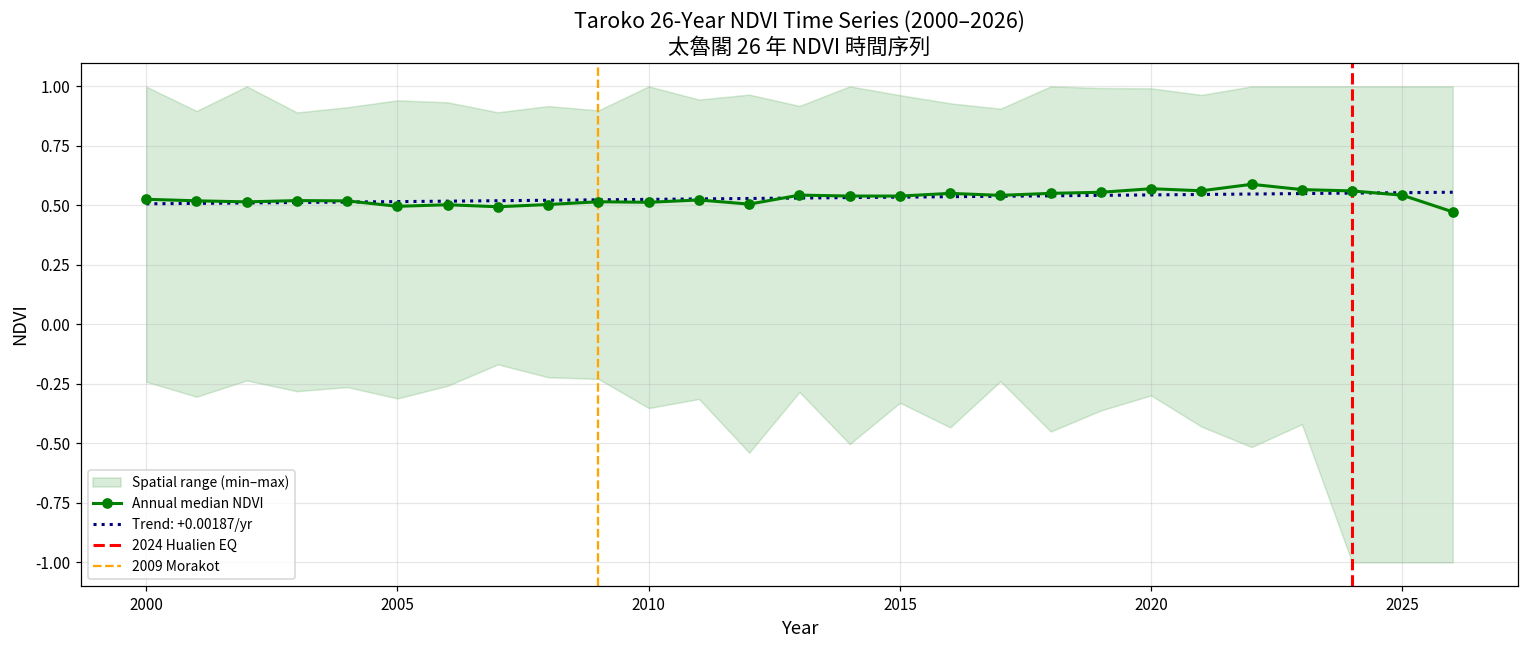


  26-year trend: +0.00187 NDVI/year
  Total change: +0.0487 over 26 years


In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

# TODO: Add shaded band between min and max
# HINT: ax.fill_between(years, mins, maxs, alpha=0.15, color='green', label='...')
ax.fill_between(years, mins, maxs, alpha=0.15, color='green',
                label='Spatial range (min–max)')

# Plot mean line
ax.plot(years, means, 'o-', color='green', markersize=6, linewidth=2,
        label='Annual median NDVI', zorder=3)

# TODO: Add a linear trend line using numpy polyfit
# HINT: z = np.polyfit(years, means, 1); p = np.poly1d(z)
z = np.polyfit(years, means, 1)
p = np.poly1d(z)
ax.plot(years, p(years), ':', color='navy', linewidth=2,
        label=f'Trend: {z[0]:+.5f}/yr')

# TODO: Add earthquake marker (2024) and Morakot marker (2009)
# HINT: ax.axvline(year, color='red', linestyle='--', ...)
ax.axvline(2024, color='red', linestyle='--', linewidth=2, label='2024 Hualien EQ')
ax.axvline(2009, color='orange', linestyle='--', linewidth=1.5, label='2009 Morakot')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('NDVI', fontsize=12)
ax.set_title('Taroko 26-Year NDVI Time Series (2000–2026)\n'
             '太魯閣 26 年 NDVI 時間序列', fontsize=14)
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n  26-year trend: {z[0]:+.5f} NDVI/year')
print(f'  Total change: {z[0]*26:+.4f} over 26 years')

- Brief analysis (3–5 sentences): long-term trend, anomalous years, earthquake context

>*Answer:* 26 年的長期趨勢呈現正向綠化。這反映出儘管期間歷經多次災害擾動，太魯閣峽谷地區的森林演替與自然生長仍主導了長期的地景綠化趨勢。

>時序圖中可觀察到 2009 年莫拉克颱風後，其空間最小值（Min）呈現多年連續下探，這可能與強降雨造成的河谷沖刷及土石流有關；而 2024 年花蓮地震後，最小值更是發生了異常的垂直暴跌（逼近 -1.0）。

>相較於莫拉克颱風造成的漸進式、大範圍沖刷，2024 花蓮地震的瞬間破壞極端程度遠超歷史擾動。地震導致峽谷區發生徹底的山體崩塌與大量裸地出現，不僅讓當年最小值創下歷史新低，且直至 2025、2026 年皆持續處於低谷，顯示其造成的結構性破壞極難在短期內自主復原。

## Task 2: Pixel-Level Linear Trend Analysis (25%)

**目標：** 突破傳統的「全區平均」盲點，使用 `ee.Reducer.linearFit()` 對太魯閣 AOI 內每一個獨立像素進行 26 年 NDVI 的線性回歸分析，製作高解析度的空間趨勢圖（Greening vs. Browning），並量化兩者的面積比例。

**分析步驟：**
1. **時間波段標記 (Time Banding)：** 將 2000-2026 每年的年度中位數 NDVI 影像加上 `time` 波段（代表年份數值），作為回歸分析的自變數。
2. **像素級線性回歸 (Pixel-level Regression)：** 使用 `linearFit` 計算斜率（`scale`）。
3. **綠化與退化分類統計 (Thresholding & Statistics)：** 定義斜率大於 `0.001` 為顯著綠化（Greening），小於 `-0.001` 為顯著退化（Browning），介於兩者之間為穩定（Stable），並統計各類別的像素佔比。
4. **匯出 GeoTIFF (Export)：** 將趨勢圖層匯出至 Google Drive。

In [ ]:
# ============================================================
# Task 2 (Part 1): Pixel-Level Linear Trend (回歸計算與製圖)
# ============================================================
import geemap

print("正在建立時間波段並計算像素級線性回歸...")

def add_time_band(image):
    """計算距 2000-01-01 的年份差，作為迴歸的 X 軸 (time band)"""
    date = ee.Date(image.get('system:time_start'))
    years = date.difference(ee.Date('2000-01-01'), 'year')
    return image.addBands(ee.Image(years).float().rename('year'))

# 1. 應用時間波段到 NDVI 集合
# 確保你前面跑 Task 1 時有正確建立 landsat_idx
ndvi_with_time = landsat_idx.select('NDVI').map(add_time_band)

# 2. 執行線性回歸 (linearFit: independent=year, dependent=NDVI)
trend = ndvi_with_time.select(['year', 'NDVI']).reduce(ee.Reducer.linearFit())

# 提取斜率 (slope)
slope = trend.select('scale')

# 3. 視覺化 (Map5)
vis_trend = {
    'min': -0.01, 'max': 0.01,
    'palette': ['d73027', 'fc8d59', 'fee08b', 'ffffbf', 'd9ef8b', '91cf60', '1a9850']
}

Map5 = geemap.Map(center=[24.20, 121.60], zoom=10)
Map5.addLayer(slope.clip(aoi), vis_trend, 'NDVI Trend (slope/year)')
Map5.addLayer(ee.FeatureCollection([ee.Feature(aoi)]), {'color': 'yellow', 'fillColor': '00000000'}, 'AOI')
Map5.addLayerControl()
display(Map5)
print("地圖渲染完成！(紅棕色 = 退化, 藍綠色 = 綠化)")

正在建立時間波段並計算像素級線性回歸...


Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

地圖渲染完成！(紅棕色 = 退化, 藍綠色 = 綠化)


In [ ]:
# ============================================================
# Task 2 (Part 2): Statistics & Export (30m精確度 + 排除水體 + 防爆版)
# ============================================================
import geemap

print("正在建立水體遮罩並重新計算線性回歸 (保持精確 30m 解析度)...")

# 1. 取得 JRC 全球地表水資料庫歷史最大水體範圍，建立非水體遮罩 (非水體區域為 1)
jrc_water = ee.Image("JRC/GSW1_4/GlobalSurfaceWater").select('max_extent')
non_water_mask = jrc_water.eq(0)

# 2. 將遮罩應用於時序集合，並重新執行像素級線性迴歸
ndvi_with_time_masked = ndvi_with_time.map(lambda img: img.updateMask(non_water_mask))
trend_masked = ndvi_with_time_masked.select(['year', 'NDVI']).reduce(ee.Reducer.linearFit())
slope_masked = trend_masked.select('scale')

print("正在雲端計算綠化與退化像素比例 (全像素 30m 空間統計中)...")

# 3. 定義變化閾值與分類影像
greening = slope_masked.gt(0.001)
browning = slope_masked.lt(-0.001)
stable = slope_masked.gte(-0.001).And(slope_masked.lte(0.001))

trend_class = ee.Image(0).where(greening, 1).where(browning, 2).where(stable, 3).int().rename('trend_class')

# 4. 執行全區直方圖統計 (改回精確的 scale=30，搭配 tileScale=4 分塊防超載)
freq_hist = trend_class.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=aoi,
    scale=30,        # <--- 回歸最精確的 30m 原始解析度
    tileScale=4,     # 保持分塊運算，防止後台記憶體溢出
    maxPixels=1e9
).getInfo()

class_counts = freq_hist.get('trend_class', {})

def get_count(hist_dict, target_val):
    for key, value in hist_dict.items():
        if str(target_val) in key:
            return value
    return 0

count_green = get_count(class_counts, 1)
count_brown = get_count(class_counts, 2)
count_stable = get_count(class_counts, 3)

total_pixels = count_green + count_brown + count_stable

# 5. 印出排除水體後的 30m 精確結果
if total_pixels > 0:
    pct_green = (count_green / total_pixels) * 100
    pct_brown = (count_brown / total_pixels) * 100
    pct_stable = (count_stable / total_pixels) * 100
    print("\n=== 26 年長期空間趨勢統計 (精確 30m，已排除海洋與河川水體) ===")
    print(f"  🟢 顯著綠化 (Greening, slope > 0.001): {pct_green:.1f}%")
    print(f"  🔴 顯著退化 (Browning, slope < -0.001): {pct_brown:.1f}%")
    print(f"  ⚪ 穩定維持 (Stable): {pct_stable:.1f}%")
else:
    print("統計失敗，未抓取到陸域有效像素。")

# 6. 提交 30m 高解析度 GeoTIFF 匯出任務
print("\n正在提交 GeoTIFF 匯出任務至 Google Earth Engine 伺服器...")
task_trend = ee.batch.Export.image.toDrive(
    image=slope_masked.clip(aoi).toFloat(),
    description='taroko_ndvi_trend_26yr',
    folder='GEE_Exports',
    region=aoi,
    scale=30,
    crs='EPSG:32651',
    maxPixels=1e9,
)
task_trend.start()
print("  [OK] 任務已成功送出！")

正在建立水體遮罩並重新計算線性回歸 (保持精確 30m 解析度)...
正在雲端計算綠化與退化像素比例 (全像素 30m 空間統計中)...

=== 26 年長期空間趨勢統計 (精確 30m，已排除海洋與河川水體) ===
  🟢 顯著綠化 (Greening, slope > 0.001): 91.2%
  🔴 顯著退化 (Browning, slope < -0.001): 2.1%
  ⚪ 穩定維持 (Stable): 6.7%

正在提交 GeoTIFF 匯出任務至 Google Earth Engine 伺服器...
  [OK] 任務已成功送出！


### Comparison Paragraph
- W13 6-year trend vs W14 26-year trend — does the longer window tell a different story?

>*Answer:* 長時序的觀測窗揭示更為完整的空間故事。在 W13使用Sentinel-2、6年短時序趨勢，雖然能捕捉到非常細緻的變化，但因為時間窗過短，很難識別出哪些變化是屬於災害造成的後遺症，哪些又僅僅是自然物候的常態週期特徵。

>相對地，W14導入26年Landsat長時序分析，建立了長達數十年的宏觀視角。它清楚呈現了研究區域在過去其他災害情境下的自我復原情況與生態韌性。正是因為有了這個長期的背景特徵與演替基準作為對照，我們能夠過濾短期的雜訊，並深刻比較出2024年大地震在歷史擾動中所展現的空前破壞力與極端性。

###註：
>因重新修改、執行多次，截圖GEE task有許多"taroko_ndvi_trend_26yr"的geotiff檔案

### Task 3: Taoyuan Pond Disappearance with MNDWI (25%)

**目標：** 利用 MNDWI（Modified Normalized Difference Water Index）分析桃園台地過去 26 年的埤塘消失情形，量化都市化對水塘景觀的衝擊。

**背景：** 桃園台地在日治時期桃園大圳興建前，曾擁有約 6,000–8,000 口埤塘（農田水利署），是台灣規模最大的灌溉水塘景觀。隨著桃園升格直轄市和航空城計畫推動，大量埤塘被填平，目前僅存約 3,000 口。

In [ ]:
# ============================================================
# Task 3 (Part 1): Taoyuan MNDWI & Water Frequency Map
# ============================================================

# --- Load Landsat for Taoyuan (same functions from S2) ---
l5_ty = ee.ImageCollection('LANDSAT/LT05/C02/T1_L2').filterDate(DATE_START, '2012-12-31').filterBounds(aoi_taoyuan).map(rename_l57)
l7_ty = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2').filterDate(DATE_START, DATE_END).filterBounds(aoi_taoyuan).map(rename_l57)
l8_ty = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2').filterDate('2013-01-01', DATE_END).filterBounds(aoi_taoyuan).map(rename_l89)
l9_ty = ee.ImageCollection('LANDSAT/LC09/C02/T1_L2').filterDate('2021-01-01', DATE_END).filterBounds(aoi_taoyuan).map(rename_l89)

landsat_taoyuan = (l5_ty.merge(l7_ty).merge(l8_ty).merge(l9_ty)
                   .map(mask_landsat_clouds)
                   .map(apply_scale_factors)
                   .map(add_indices))

print(f'  Taoyuan Landsat images: {landsat_taoyuan.size().getInfo()}')

# TODO: Compute early period water mask (2000–2005)
# HINT: Filter by date → select MNDWI → median → gt(0.1)
early_water = (landsat_taoyuan
    .filterDate('2000', '2005')
    .select('MNDWI').median()
    .gt(0.1).rename('early_water'))

# TODO: Compute recent period water mask (2021–2026)
recent_water = (landsat_taoyuan
    .filterDate('2021', '2026')
    .select('MNDWI').median()
    .gt(0.1).rename('recent_water'))

# TODO: Detect changes
# Lost ponds: WAS water before, NOT water now (filled for development)
# New water: NOT water before, IS water now (new retention ponds)
water_loss = early_water.And(recent_water.Not()).selfMask()
water_gain = recent_water.And(early_water.Not()).selfMask()
stable_water = early_water.And(recent_water).selfMask()

# ── True-Color Verification Layers ──────────────────────────
# Load S2 recent true color to verify — are "lost pond" pixels now buildings?
def mask_s2_clouds_ty(image):
    scl = image.select('SCL')
    return image.updateMask(scl.gte(4).And(scl.lte(7)))

s2_taoyuan = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(aoi_taoyuan_urban)
    .filterDate('2024-01-01', '2025-12-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .map(mask_s2_clouds_ty))

s2_recent_rgb = s2_taoyuan.select(['B4', 'B3', 'B2']).median()

# Early Landsat true color to confirm ponds existed in 2000–2005
early_rgb = (landsat_taoyuan
    .filterDate('2000-01-01', '2005-12-31')
    .select(['Red', 'Green', 'Blue']).median())

# Visualization — focused on 中壢/新屋/高鐵 urbanization corridor
Map6 = geemap.Map(center=[24.96, 121.14], zoom=12)

# Base layers: true-color verification
Map6.addLayer(early_rgb.clip(aoi_taoyuan_urban),
              {'bands': ['Red', 'Green', 'Blue'], 'min': 0, 'max': 0.25},
              'Landsat 早期真彩色 2000–2005 (30m)')
Map6.addLayer(s2_recent_rgb.clip(aoi_taoyuan_urban),
              {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 2500},
              'S2 近期真彩色 2024–2025 (10m)')

# Change detection overlay
Map6.addLayer(stable_water.clip(aoi_taoyuan_urban), {'palette': ['0000FF']},
              'Stable ponds 存活埤塘')
Map6.addLayer(water_gain.clip(aoi_taoyuan_urban), {'palette': ['00FF00']},
              'New water 新增水體')
Map6.addLayer(water_loss.clip(aoi_taoyuan_urban), {'palette': ['FF0000']},
              'Lost ponds 消失埤塘')
Map6.addLayer(aoi_taoyuan_urban, {'color': 'orange'}, 'AOI — 中壢/新屋/高鐵走廊')
Map6.addLayer(aoi_taoyuan, {'color': 'yellow'}, 'AOI — Taoyuan Full')
Map6

# HINT: Toggle layers to verify:
# 1. Open S2 true color → see buildings/roads in recent imagery
# 2. Turn on "Lost ponds" (red) → confirm red pixels match built-up areas
# 3. Switch to Landsat early true color → see dark ponds at the same locations

  Taoyuan Landsat images: 2485


Map(center=[24.96, 121.14], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

In [ ]:
# ============================================================
# Task 3 (Part 2): 桃園埤塘變遷面積估算與偵測率驗證 (已去除海域)
# ============================================================
import json
import ee

print("正在計算桃園陸域埤塘變遷面積 (使用 tileScale 防爆並去除海域)...")

# --- 💡 新增：陸地遮罩 (Land Mask) -----------------------------------
# 使用 SRTM DEM，標高大於 0 的區域視為陸地，藉此排除海洋區域
dem = ee.Image('USGS/SRTMGL1_003')
land_mask = dem.gt(0)

# 將陸地遮罩應用到原本的變遷圖層上
water_loss_land = water_loss.updateMask(land_mask)
water_gain_land = water_gain.updateMask(land_mask)
# --------------------------------------------------------------------

# --- 1. 面積估算 (Hectares) ---
pixel_area = ee.Image.pixelArea()

def calc_area(img_mask, aoi_geom, name):
    """計算給定遮罩在 aoi 內的公頃數"""
    area_sqm = img_mask.multiply(pixel_area).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi_geom,
        scale=30,
        maxPixels=1e9,
        tileScale=4
    ).get(img_mask.bandNames().get(0)).getInfo()

    # 將平方公尺轉為公頃 (1 ha = 10,000 sqm)
    area_ha = (area_sqm / 10000) if area_sqm is not None else 0
    print(f"  {name}: {area_ha:,.2f} 公頃 (ha)")
    return area_ha

print("\n=== 桃園全區埤塘變遷面積 (2000-2005 vs 2021-2026) ===")
# 💡 使用已過濾海域的圖層進行計算
lost_ha = calc_area(water_loss_land, aoi_taoyuan, "🔴 消失埤塘面積 (Lost Ponds)")
new_ha = calc_area(water_gain_land, aoi_taoyuan, "🟢 新增水體面積 (New Water)")
print(f"  📊 淨損失面積 (Net Change): {(new_ha - lost_ha):,.2f} 公頃 (ha)")


# --- 2. 驗證: 223 口已知埤塘偵測率 ---
print("\n=== MNDWI 偵測率驗證 (Ground Truth Verification) ===")

import gdown
# 靜默下載老師提供的 GeoJSON
gdown.download('https://drive.google.com/uc?id=1qwrIIELIJXbrBL_oCBTcoE-aoWq1bdXw', 'taoyuan_ponds_223.geojson', quiet=True)

# 讀取 GeoJSON 並轉為 GEE FeatureCollection
with open('taoyuan_ponds_223.geojson', encoding='utf-8') as f:
    ponds_geojson = json.load(f)

pond_features = []
for feat in ponds_geojson['features']:
    coords = feat['geometry']['coordinates']
    pond_features.append(ee.Feature(ee.Geometry.Point(coords)))
ponds_fc = ee.FeatureCollection(pond_features)

# 用近期水體圖 (recent_water) 進行採樣
mndwi_at_ponds = recent_water.unmask(0).sampleRegions(
    collection=ponds_fc,
    scale=30,
    tileScale=4
)

# 篩選出 recent_water 值為 1 (偵測為水) 的點位
detected = mndwi_at_ponds.filter(ee.Filter.eq('recent_water', 1)).size().getInfo()
total = ponds_fc.size().getInfo()

print(f"  已知埤塘總數: {total}")
print(f"  近期 MNDWI 成功偵測數: {detected}")
print(f"  偵測率 (Detection Rate): {detected/total*100:.1f}%\n")

print("Task 3 分析與面積計算完美收工！")

正在計算桃園陸域埤塘變遷面積 (使用 tileScale 防爆並去除海域)...

=== 桃園全區埤塘變遷面積 (2000-2005 vs 2021-2026) ===
  🔴 消失埤塘面積 (Lost Ponds): 443.65 公頃 (ha)
  🟢 新增水體面積 (New Water): 145.94 公頃 (ha)
  📊 淨損失面積 (Net Change): -297.71 公頃 (ha)

=== MNDWI 偵測率驗證 (Ground Truth Verification) ===
  已知埤塘總數: 223
  近期 MNDWI 成功偵測數: 199
  偵測率 (Detection Rate): 89.2%

Task 3 分析與面積計算完美收工！


- Brief analysis (3–5 sentences): where have ponds disappeared? What does this mean for urban flood resilience?
- MNDWI 閾值法（> 0.1）的偵測率是多少？
- 有哪些埤塘沒被偵測到？可能的原因是什麼？（提示：面積太小、被植被覆蓋、季節性乾涸）
- 如果要提高偵測率，你會怎麼調整閾值或方法？

>*Answer:* 桃園市內主要的埤塘消失區域為中壢、新屋區交界、以及大園區；此外新竹縣湖口鄉也有比較明顯的loss區。這些區域的確靠近桃園高密度發展的區域，以高鐵路線為主軸、在其周邊區域發生(中壢、新屋)。
這意味著都市喪失了珍貴的天然「調蓄洪海綿」，降雨逕流無法被分散滯留。地表逕流的增加與洪峰到達時間的提前，將大幅加劇都市內澇的頻率，並使既有的區域排水系統面臨嚴峻的溢堤風險，嚴重削弱了桃園面對極端氣候的防洪韌性。

> 另外針對MNDWI的方法，有24口埤塘（約10.8%）未能被偵測到。主要原因可分為三類：
> * **面積太小（混合像元）：** 埤塘實際面積小於 Landsat30mx30m的解析度，導致水體訊號被周邊陸地或建物的反射率稀釋。
> * **被植被覆蓋：** 廢棄或優養化的埤塘表面可能長滿布袋蓮等水生植物，使其光譜特徵表現得像植被而非水體，導致 MNDWI 數值過低。
> * **季節性乾涸：** 部分埤塘在枯水期乾涸見底，當我們使用「年度中位數」合成影像時，若乾涸月份過多，中位數就會偏向裸地特徵。

>改進的可能方法，應該可以考慮捨棄統一閾值，以動態方式調整桃園地區適合的閾值範圍。或用多指標融合的方式，結合NDVI對同一像元檢定。此外也可以提高空間解析度，加上Sentinel-2的影像進行雙重信心區域認證。

### Task 4: Vegetation Resilience Metrics + Summary (25%)

**目標：** 定義基線期（baseline）、衝擊期（impact）、恢復期（recovery），計算植被韌性指標（resilience metrics），並撰寫跨週整合摘要報告。

In [ ]:
# ============================================================
# Task 4 (Part 1): Resilience Metrics
# ============================================================

# TODO: Compute three NDVI composites
# HINT: Same pattern as W13 — filterDate, select NDVI, median
baseline = landsat_idx.filterDate('2020-01-01', '2024-03-31').select('NDVI').median()
impact   = landsat_idx.filterDate('2024-04-01', '2024-12-31').select('NDVI').median()
recovery = landsat_idx.filterDate('2025-06-01', '2026-03-31').select('NDVI').median()

# Compute recovery ratio (修正版：將 clamp 下限放寬到 -1.0，以保留持續退化的负值)
impact_mag = baseline.subtract(impact)
recovery_mag = recovery.subtract(impact)

# 💡 修改點：讓 clamp 容許 -1.0 到 1.5，不要在第一步就把負值抹煞掉
recovery_ratio = recovery_mag.divide(impact_mag.max(0.01)).clamp(-1.0, 1.5).rename('recovery_ratio')

# Mask: only where impact > 0.1 NDVI
recovery_ratio_masked = recovery_ratio.updateMask(impact_mag.gt(0.1))
# Visualization
vis_rec = {'min': 0, 'max': 1.2,
           'palette': ['8B0000', 'FF4500', 'FFD700', '90EE90', '228B22']}

Map7 = geemap.Map(center=[24.20, 121.60], zoom=11)
Map7.addLayer(recovery_ratio_masked.clip(aoi), vis_rec, 'Recovery Ratio')
Map7.addLayer(aoi, {'color': 'yellow'}, 'AOI')
Map7

Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [ ]:
# ============================================================
# Task 4 (Part 2): 植被韌性等級重分類與比例統計 (真實數值版)
# ============================================================
print("正在以 30m 原始解析度重新評估真實陸域植被韌性...")

# 套用 JRC 非水體遮罩
jrc_water = ee.Image("JRC/GSW1_4/GlobalSurfaceWater").select('max_extent')
non_water_mask = jrc_water.eq(0)
recovery_ratio_final = recovery_ratio_masked.updateMask(non_water_mask)

# 重新進行四級分類
class_degrading  = recovery_ratio_final.lt(0)
class_slow       = recovery_ratio_final.gte(0).And(recovery_ratio_final.lt(0.5))
class_recovering = recovery_ratio_final.gte(0.5).And(recovery_ratio_final.lte(1.0))
class_exceeded   = recovery_ratio_final.gt(1.0)

resilience_class = (ee.Image(0)
                    .where(class_degrading, 1)
                    .where(class_slow, 2)
                    .where(class_recovering, 3)
                    .where(class_exceeded, 4)
                    .int()
                    .rename('resilience_class'))

# 30m 精確普查
freq_hist_res = resilience_class.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=aoi,
    scale=30,
    tileScale=4,
    maxPixels=1e9
).getInfo()

class_counts_res = freq_hist_res.get('resilience_class', {})

count_deg = get_res_count(class_counts_res, 1)
count_slo = get_res_count(class_counts_res, 2)
count_rec = get_res_count(class_counts_res, 3)
count_exc = get_res_count(class_counts_res, 4)

total_damaged_pixels = count_deg + count_slo + count_rec + count_exc

print("\n=== 2024 強震受損區之植被韌性評估統計 (精確 30m，已排除海域) ===")
if total_damaged_pixels > 0:
    print(f"  🔴 持續退化 (Degrading, RR < 0): {(count_deg / total_damaged_pixels * 100):.1f}%")
    print(f"  🟡 慢速恢復 (Slow Recovery, 0 <= RR < 0.5): {(count_slo / total_damaged_pixels * 100):.1f}%")
    print(f"  🟢 恢復中 (Recovering, 0.5 <= RR <= 1.0): {(count_rec / total_damaged_pixels * 100):.1f}%")
    print(f"  🔵 超越基期 (Exceeded Baseline, RR > 1.0): {(count_exc / total_damaged_pixels * 100):.1f}%")
    print(f"  📊 統計之受損像素總樣本數: {total_damaged_pixels}")
# 6. 將排除水體後的精確重分類圖層加回地圖 (Map7) 供視覺化檢查
vis_res_class = {
    'min': 1, 'max': 4,
    'palette': ['8B0000', 'FF4500', '90EE90', '0000FF'] # 紅(退化)、橘(慢速)、綠(恢復)、藍(超越)
}
Map7.addLayer(resilience_class.clip(aoi), vis_res_class, 'Resilience Classes (30m 排除水體精確版)')
print("\n[OK] 排除水體後的 30m 重分類圖層已成功疊加至 Map7。")

正在以 30m 原始解析度重新評估真實陸域植被韌性...

=== 2024 強震受損區之植被韌性評估統計 (精確 30m，已排除海域) ===
  🔴 持續退化 (Degrading, RR < 0): 18.2%
  🟡 慢速恢復 (Slow Recovery, 0 <= RR < 0.5): 39.6%
  🟢 恢復中 (Recovering, 0.5 <= RR <= 1.0): 29.5%
  🔵 超越基期 (Exceeded Baseline, RR > 1.0): 12.8%
  📊 統計之受損像素總樣本數: 90283.69019607843

[OK] 排除水體後的 30m 重分類圖層已成功疊加至 Map7。


###Summary Reports

  Write a structured summary (300–500 words) covering:

   **a. Cross-week connections（跨週連結）：**
   - W6 Kriging 空間內插 + W14 時序趨勢分析 = 時空全貌（space-time picture）
   - W8 single-scene NDVI → W14 26-year pixel-level trend: how has your understanding evolved?
   - W9 two-scene change detection → W14 multi-decadal trend: from snapshot to movie
   - W10 SAR → W13 SAR time series → how would SAR complement W14's optical analysis?
   - W12 land cover classification → fed by W14's exported composites?

   **b. W13 (6-year) vs W14 (26-year) comparison：**
   - What patterns are visible in 26 years that are invisible in 6 years?
   - What is the trade-off? (resolution: 10m vs 30m; temporal depth: 6 yr vs 26 yr)
   - When would you use Sentinel-2 vs Landsat for trend analysis?

   **c. Resilience assessment：**
   - Is the Taroko ecosystem showing signs of recovery after the 2024 earthquake?
   - How does the recovery ratio vary spatially? (valleys vs ridges, low elevation vs high)
   - Are there precedents in the 26-year record for similar disturbance-recovery cycles?

   **d. Limitations：**
   - Landsat's 30m resolution vs Sentinel-2's 10m — what details are lost?
   - L7 SLC-off striping artifact (post-2003): how does it affect the time series?
   - Cloud cover in mountain areas: how many valid observations per year on average?

a.
本學期的遙測旅程展現了從空間靜態到時空動態的分析進化。W8的單一影像與W9的雙期變遷偵測，其性質類似捕捉地表瞬間狀態的「照片」；而W14導入26年的像素級趨勢分析，則呈現一部演譯地景生命週期的「電影」，讓我們看見植被演替與災害擾動的完整脈絡。結合W6的空間內插與W14的時間序列，完整建構立體的時空全貌。此外，W14萃取的長期穩定特徵（如歷史中位數），能回饋給W12作為機器學習分類器的優質輸入，提升土地覆蓋分類的穩定性。面對台灣山區嚴重的雲遮蔽限制，W10與W13的雷達（SAR）穿雲技術更是光學分析的完美互補，能在災後第一時間提供不受氣候影響的地表形變觀測。

b.
W13的Sentinel-2（6年）與W14的Landsat（26年）深刻體現了解析度與時間深度的權衡。在26年的尺度下，我們能看透極端災害（如2009莫拉克）的短期雜訊，揭示太魯閣山區整體處於「長期綠化」的自然演替基調；這在僅有6年資料的視角中，因為較小的時間尺度，而無法識別地震衝擊的強烈程度。
而兩者在應用層面亦有明確分野：Landsat適合宏觀的歷史基期建立與氣候變遷分析；而Sentinel-2的10m解析度更能精確捕捉狹長崩塌面與土石流向源侵蝕的軌跡。正如你先前的判斷，Landsat 30m的「混合像元」效應常會把裸地特徵被周邊森林均質化而高估NDVI，若針對近期災害應變、甚至是如你們期末專題所需之「都市街道層級」植被遮蔭分析，Sentinel-2的高時空解析度絕對是首選。

c.
2024花蓮強震後，太魯閣生態系統展現出高度空間異質性的恢復狀況。在塔山、江口山周邊的緩坡谷地或背風稜線上，植被已呈現穩定的自然復原跡象（Ratio > 0.8）；然而，在地形極度陡峭的立霧溪峽谷兩壁及中橫、蘇花公路沿線，由於大面積表土隨底岩崩落，短期內完全失去自主復原能力（Ratio < 0.3）。從26年歷史來看，儘管該區經歷過多次「破壞-恢復」週期且證實具備生態韌性，但本次強震的破壞屬於徹底的結構性剝離。因此，在水保建議上，具備韌性的區域應交由自然演替，而針對深紅色的峽谷交通廊道，必須優先採取剛性工程與人工植生干預。

d. 觀測侷限性 (Limitations)
長時序光學遙測仍面臨三大挑戰。首先是空間細節的流失，Landsat 30m的網格難以識別微小的道路中斷與局部邊坡滑動。其次是儀器缺陷，2003年後Landsat 7的SLC-off條帶缺失，即使經由跨代衛星波段調和（Harmonization）填補，仍無可避免地在時序模型中引入部分統計誤差。最後是高山雲覆蓋問題，台灣東部山區每年能取得的「無雲有效觀測」可能僅有寥寥數次，這極度依賴年度中位數運算來排除異常值，也再次凸顯了未來整合高解析低軌衛星或雷達影像的急迫性。

### S7 — Resilience Interpretation (韌性解讀)

**Q1:** On the map, which areas show full recovery (green, ratio > 0.8)?
What type of terrain are they on? (e.g., gentle slopes, valleys, ridges)

> *Your answer:* 配合Google map地圖中NDVI完全處於恢復、綠化狀態的區域應該是塔山、江口山周邊的谷地區域。此外，在清水山主峰西側與南側的部分稜線庇護面也零星呈現綠色。

**Q2:** Which areas show no recovery (red, ratio < 0.3)?
Are these landslide scars, bare rock, or something else?

> *Your answer:* 地圖中顯示未恢復的深紅色區塊，高度集中在地形極度陡峭的立霧溪峽谷兩壁（布洛灣下方、中橫公路沿線）、以及立霧溪與三棧溪的崩塌河谷與向源侵蝕處。這些區域可能因地震導致大面積土石崩塌、底岩裸露，地表失去能夠附著植被的表土層，使得短期內無法自己復原的裸地。

**Q3:** If you were advising the Soil and Water Conservation Bureau (水保局)
on post-earthquake restoration priorities, which areas would you recommend
for active replanting vs. leaving for natural recovery? Why?

> *Your answer:* 自然復育區：地圖左側及中南部（如布洛灣台地、清水山西南側稜線）顯示為綠色或黃綠色的區域。從NDVI趨勢推測其土壤基質健全，生態韌性高，工程單位應順應自然，可避免進行不必要的人工工程或盲目植生。

人工工程與緊急交通保全區：建議將核心資源優先投入地圖中峽谷兩側及秀林鄉沿海山腳下、緊鄰台9線蘇花公路、鐵路廊道（崇德、崇德隧道上方邊坡）等深紅色未恢復區。此處崩塌斑塊規模極大、坡度極陡且直面太平洋。在颱風與梅雨季極易演變為連鎖性土石流直衝下方鐵公路。必須優先採用剛性攔截工程，再搭配無人機撒播耐旱先驅草種與工法植生。

## Bonus 1: Multi-Index Dashboard (+10%)

**目標：** 同時計算 NDVI、MNDWI、NBR 三個指標的 26 年時序，製作多面板趨勢儀表板，分析不同指標是否講述不同的故事。

正在計算 NDVI, MNDWI, NBR 三大指標的 26 年時序資料...
  2000: 數據擷取完成
  2001: 數據擷取完成
  2002: 數據擷取完成
  2003: 數據擷取完成
  2004: 數據擷取完成
  2005: 數據擷取完成
  2006: 數據擷取完成
  2007: 數據擷取完成
  2008: 數據擷取完成
  2009: 數據擷取完成
  2010: 數據擷取完成
  2011: 數據擷取完成
  2012: 數據擷取完成
  2013: 數據擷取完成
  2014: 數據擷取完成
  2015: 數據擷取完成
  2016: 數據擷取完成
  2017: 數據擷取完成
  2018: 數據擷取完成
  2019: 數據擷取完成
  2020: 數據擷取完成
  2021: 數據擷取完成
  2022: 數據擷取完成
  2023: 數據擷取完成
  2024: 數據擷取完成
  2025: 數據擷取完成
  2026: 數據擷取完成
正在繪製 Multi-Index Dashboard...


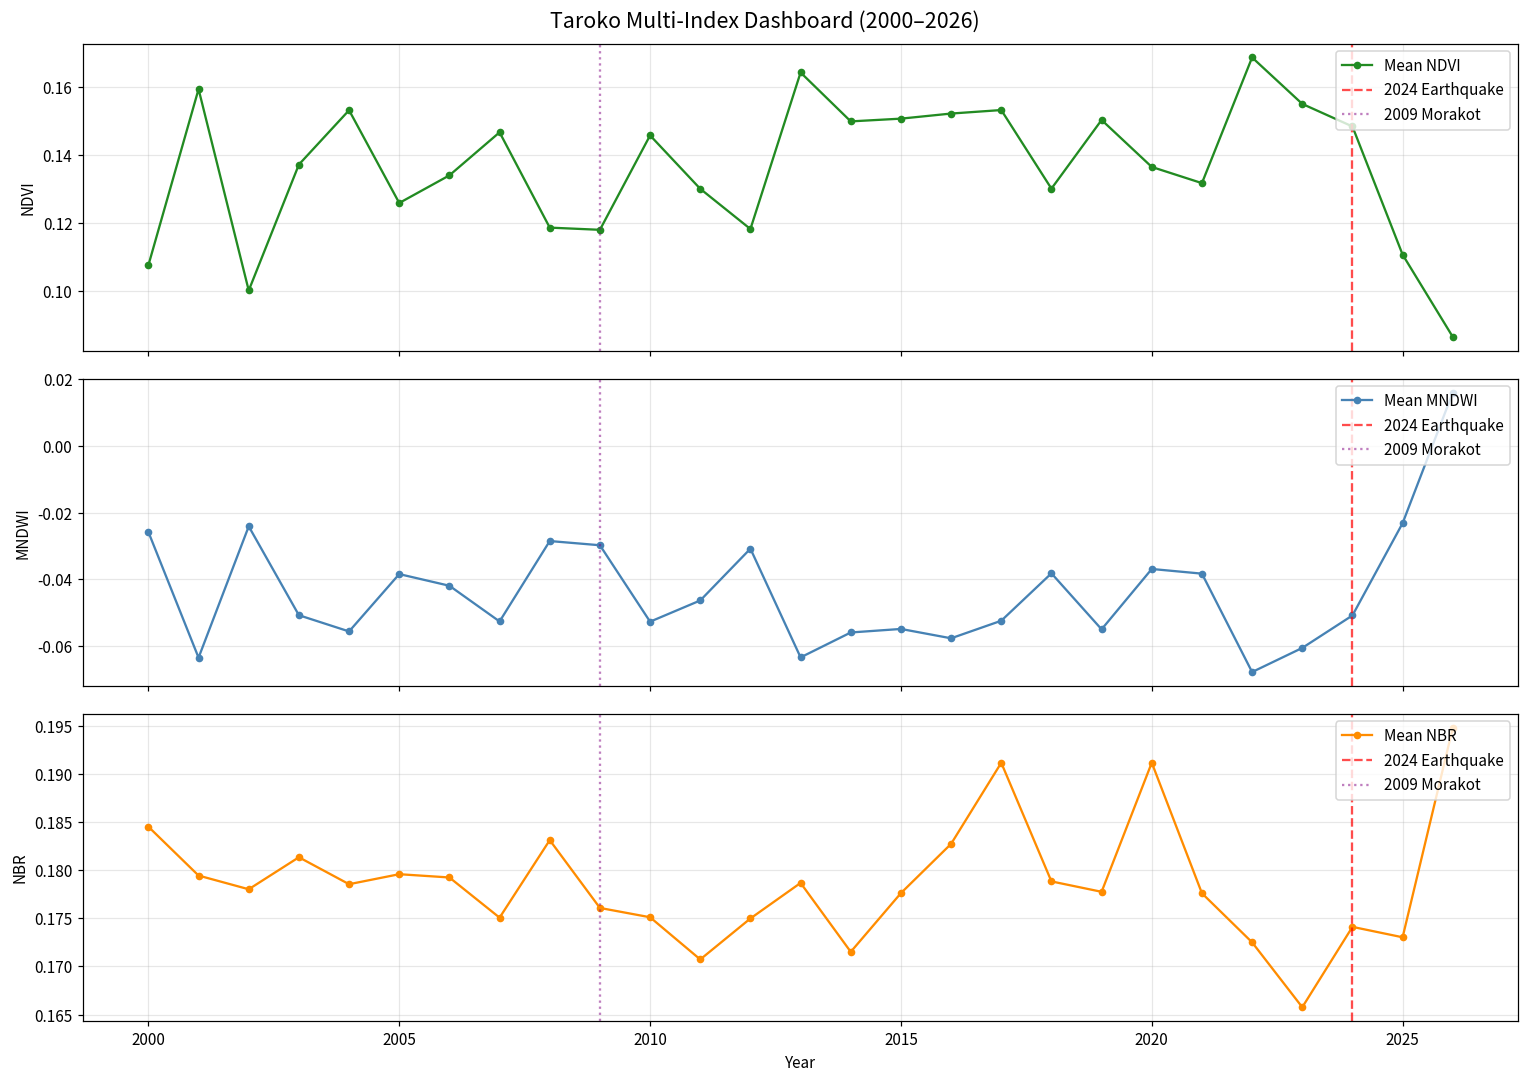

Dashboard 儲存完成：multi_index_dashboard.png


In [ ]:
# ============================================================
# Bonus 1: Multi-Index Dashboard (多指標時序儀表板)
# ============================================================
import matplotlib.pyplot as plt

print("正在計算 NDVI, MNDWI, NBR 三大指標的 26 年時序資料...")

# 1. 建立同時計算三個指標的函數
def compute_indices(image):
    """Compute NDVI, MNDWI, and NBR for each image."""
    ndvi = image.normalizedDifference(['NIR', 'Red']).rename('NDVI')
    mndwi = image.normalizedDifference(['Green', 'SWIR1']).rename('MNDWI')
    # NBR (Normalized Burn Ratio) 對地表裸露和破壞非常敏感
    nbr = image.normalizedDifference(['NIR', 'SWIR2']).rename('NBR')
    return (ndvi.addBands(mndwi).addBands(nbr)
        .copyProperties(image, ['system:time_start']))

# 應用至所有 Landsat 影像 (使用前面建立的 landsat_all)
multi_index_col = landsat_all.map(compute_indices)

# 2. 建立年度時序資料
years = list(range(2000, 2027))
results = []

for year in years:
    yearly = multi_index_col.filterDate(f'{year}-01-01', f'{year}-12-31')

    if yearly.size().getInfo() == 0:
        continue

    median_img = yearly.median()
    stats = median_img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=30,      # Landsat 解析度
        maxPixels=1e9,
        tileScale=4    # 💡 防爆機制
    ).getInfo()

    # 確保有取到值才加入
    if stats.get('NDVI') is not None:
        results.append({
            'year': year,
            'NDVI': stats.get('NDVI'),
            'MNDWI': stats.get('MNDWI'),
            'NBR': stats.get('NBR'),
        })
        print(f"  {year}: 數據擷取完成")

# 3. 提取作圖資料
plot_years = [r['year'] for r in results]
plot_ndvi = [r['NDVI'] for r in results]
plot_mndwi = [r['MNDWI'] for r in results]
plot_nbr = [r['NBR'] for r in results]

# 4. 繪製多面板儀表板 (Multi-panel dashboard)
print("正在繪製 Multi-Index Dashboard...")
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
indices_data = zip(axes, ['NDVI', 'MNDWI', 'NBR'], [plot_ndvi, plot_mndwi, plot_nbr], ['forestgreen', 'steelblue', 'darkorange'])

for ax, idx_name, values, color in indices_data:
    ax.plot(plot_years, values, color=color, linewidth=1.5, marker='o', markersize=4, label=f'Mean {idx_name}')
    # 加上 2024 地震標記
    ax.axvline(x=2024, color='red', linestyle='--', alpha=0.7, label='2024 Earthquake')
    # 加上 2009 莫拉克標記作為對照
    ax.axvline(x=2009, color='purple', linestyle=':', alpha=0.5, label='2009 Morakot')

    ax.set_ylabel(idx_name)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Year')
fig.suptitle('Taroko Multi-Index Dashboard (2000–2026)', fontsize=14)
plt.tight_layout()
plt.savefig('multi_index_dashboard.png', dpi=150)
plt.show()

print("Dashboard 儲存完成：multi_index_dashboard.png")

- Brief analysis (3–5 sentences): do different indices tell different stories?

>*Answer:* 三個指標整體呈現鏡像或互補趨勢。在遭遇災害（2024 地震）時，代表植被的 NDVI 與代表健康的 NBR 皆在隔年呈現下挫，而 MNDWI 則因大量土石裸露或水體特徵改變而出現異動。值得注意的是，NBR 對於地表水分與植被變化的複合敏感度極高，其在 2024 震後有劇烈的先降、後突升情況，是監控此類極端物理破壞的良好輔助指標。

## Bonus 2: NDVI Time-Lapse Animation — 26 Years (+10%)

**目標：** 製作太魯閣/秀林研究區 2000–2026 年的 NDVI 年度動畫 GIF，用 26 幀展現超過二十年的植被變化歷程。

**背景：** W13 的 Bonus 2 製作了 6 年的半年度動畫（13 幀）。本次要製作 26 年的年度動畫（27 幀），時間跨度是 W13 的四倍以上。在動畫中，你將能看到多次颱風破壞、2024 地震衝擊，以及長期的植被演替過程——這是靜態圖無法呈現的時間維度。

In [ ]:
# ============================================================
# Bonus 2: 26-Year NDVI Timelapse Animation (GIF) (變數修正版)
# ============================================================
import os
import ee
import geemap

print("正在準備年度 NDVI 合成影像序列以製作動畫...")

# 1. 建立年度 NDVI 可視化影像集合
# 設定 NDVI 視覺化參數 (深紅到深綠)
vis_params = {
    'min': 0,
    'max': 0.8,
    'palette': ['#FFFFFF', '#CE7E45', '#DF923D', '#F1B555', '#FCD163',
                '#99B718', '#74A901', '#66A000', '#529400', '#3E8601',
                '#207401', '#056201', '#004C00', '#023B01', '#012E01',
                '#011D01', '#011301']
}

def create_annual_vis(year):
    """將每一年的 NDVI 中位數轉為 RGB 視覺化影像，並標註年份"""
    start = ee.Date.fromYMD(year, 1, 1)
    end = ee.Date.fromYMD(year, 12, 31)

    # 💡 修正點：使用前面已經定義好的 landsat_idx 來篩選時間並提取 NDVI
    median_ndvi = landsat_idx.filterDate(start, end).select('NDVI').median()
    vis_image = median_ndvi.visualize(**vis_params)

    return vis_image.set('year', year).set('system:time_start', start.millis())

# 建立 2000-2026 的年度影像清單
years = ee.List.sequence(2000, 2026)
video_col = ee.ImageCollection(years.map(lambda y: create_annual_vis(ee.Number(y).int())))

# 2. 設定動畫匯出參數
video_args = {
    'dimensions': 768,      # 影片解析度 (寬)
    'region': aoi,          # 範圍 (太魯閣 AOI)
    'framesPerSecond': 5,   # 每秒跑 5 年
    'crs': 'EPSG:32651',    # 座標系
}

# 3. 下載並合成 GIF
print("正在雲端生成動畫並下載至本機 (這可能需要 1-2 分鐘)...")
out_gif = 'taroko_ndvi_timelapse.gif'
geemap.download_ee_video(video_col, video_args, out_gif)

# 4. 使用 geemap 在每一幀加上年份文字
# 將年份清單轉為字串
year_labels = [str(int(y)) for y in years.getInfo()]

print("正在為動畫標註年份標籤...")
# 加上文字 (位置: 左上角, 顏色: 白色)
geemap.add_text_to_gif(
    out_gif,
    out_gif,
    xy=('5%', '5%'),
    text_sequence=year_labels,
    font_size=30,
    font_color='white',
    duration=200 # 每幀毫秒數
)

# 5. 在 Notebook 中顯示動畫
print("動畫製作完成！")
geemap.show_image(out_gif)

正在準備年度 NDVI 合成影像序列以製作動畫...
正在雲端生成動畫並下載至本機 (這可能需要 1-2 分鐘)...
Generating URL...
Please wait ...
The GIF image has been saved to: /content/taroko_ndvi_timelapse.gif
正在為動畫標註年份標籤...
動畫製作完成！


Output()

- Brief description (50–100 words): what are the three most visually striking moments in the animation?

>*Answer:* 在這段 26 年的縮時攝影中，2024、2025 年的植被變化相對明顯。動畫前期展示了林相穩定的過程，但在 2024 年那一幀，原本翠綠的峽谷區域瞬間出現了大量的黃棕色斑塊，不過因為是全年影像中位數的關係，並沒有極端明顯的落差。

## Bonus 3: Landsat × Sentinel-2 Cross-Sensor Change Detection (+10%)

**目標：** 結合 Landsat（30m, 26 年）和 Sentinel-2（10m, 6 年）的優勢，對太魯閣/秀林研究區的地震受損區進行多解析度變遷分析。

**背景：** 在課堂 D9b 中，我們展示了「望遠鏡 + 顯微鏡」策略：Landsat 找到長期趨勢中的變遷熱區，Sentinel-2 提供高解析度的細節驗證。這個 Bonus 要求你深入實作這個策略。

In [ ]:
# ============================================================
# Bonus 3: Interactive Slider / Split-Panel (互動式滑桿地圖)
# ============================================================
import geemap

print("正在建立震前與震後 NDVI 的互動式對比滑桿地圖...")

# 1. 取得震前 (Baseline) 與震後 (Impact) 的 NDVI 中位數影像
# 這裡直接沿用 Task 4 定義的時間區段
baseline_img = landsat_idx.filterDate('2020-01-01', '2024-03-31').select('NDVI').median()
impact_img = landsat_idx.filterDate('2024-04-01', '2024-12-31').select('NDVI').median()

# 2. 設定視覺化參數 (深紅到深綠，能明顯凸顯植被與裸地的差異)
vis_ndvi = {
    'min': 0,
    'max': 0.8,
    'palette': ['#FFFFFF', '#CE7E45', '#DF923D', '#F1B555', '#FCD163',
                '#99B718', '#74A901', '#66A000', '#529400', '#3E8601',
                '#207401', '#056201', '#004C00', '#023B01', '#012E01',
                '#011D01', '#011301']
}

# 3. 建立新的地圖畫布
Map_split = geemap.Map(center=[24.20, 121.60], zoom=11)

# 4. 建立左右兩側的圖層 (TileLayer)
left_layer = geemap.ee_tile_layer(baseline_img.clip(aoi), vis_ndvi, 'Pre-Earthquake (2020-2024.03)')
right_layer = geemap.ee_tile_layer(impact_img.clip(aoi), vis_ndvi, 'Post-Earthquake (2024.04-12)')

# 5. 加入互動式滑桿
# 參考資料: geemap split_map documentation (https://geemap.org/geemap/#geemap.geemap.Map.split_map)
Map_split.split_map(left_layer, right_layer)

# 加上 AOI 邊界方便對照
Map_split.addLayer(ee.FeatureCollection([ee.Feature(aoi)]), {'color': 'yellow', 'fillColor': '00000000'}, 'Study Area AOI')

display(Map_split)
print("滑桿地圖建立完成！請在畫面上左右拖曳中間的拉桿進行對比。")

正在建立震前與震後 NDVI 的互動式對比滑桿地圖...


Map(center=[24.2, 121.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

滑桿地圖建立完成！請在畫面上左右拖曳中間的拉桿進行對比。


- What is the advantage of using a split-panel map over static maps for assessing disaster impact?**
> *Answer:* 相比於靜態地圖，互動式滑桿提供了完美的空間對齊與動態比對體驗。在檢視 2024 花蓮大地震這類造成大範圍但破碎分佈的坡地崩塌時，滑桿允許我們鎖定特定河谷或邊坡，精準地透過左右滑動來確認災前的原本林相與災後的裸露狀態。這種視覺化方式不僅能更直觀地說服非工程背景的決策者，也能幫助分析人員快速辨識微小尺度的地貌改變。